In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_pickle("dataset.pkl")

In [9]:
df.head()

,task,world,robot,overall_score,task_success,metric_action_validity_score,metric_action_validity_status,metric_action_validity_weight,metric_capability_score,metric_capability_status,...,metric_sequence_status,metric_sequence_weight,metric_skill_mapping_score,metric_skill_mapping_status,metric_skill_mapping_weight,metric_task_success_score,metric_task_success_status,metric_task_success_weight,plan,evaluation
0,1,apartment,h2,0.7300,False,1.0,PASS,0.1,0.0,FAIL,...,PASS,0.07,1.0,PASS,0.15,0.0,WARNING,0.02,"{'metadata': {'robot': 'H2', 'world': 'Apartme...","{'report_version': '1.0', 'generated_at': '202..."
1,1,apartment,pepper,1.0000,True,1.0,PASS,0.1,1.0,PASS,...,PASS,0.07,1.0,PASS,0.15,1.0,PASS,0.02,"{'metadata': {'robot': 'JulietteY20MP', 'world...","{'report_version': '1.0', 'generated_at': '202..."
2,1,hospital,nao,0.9800,False,1.0,PASS,0.1,1.0,PASS,...,PASS,0.07,1.0,PASS,0.15,0.0,WARNING,0.02,"{'metadata': {'robot': 'nao', 'world': 'Multi-...","{'report_version': '1.0', 'generated_at': '202..."
3,1,hospital,pepper,0.8467,True,1.0,PASS,0.1,1.0,PASS,...,PASS,0.07,1.0,PASS,0.15,1.0,PASS,0.02,"{'metadata': {'robot': 'JulietteY20MP', 'world...","{'report_version': '1.0', 'generated_at': '202..."
4,1,kitchen,h2,0.6500,False,1.0,PASS,0.1,0.0,FAIL,...,PASS,0.07,1.0,PASS,0.15,0.0,WARNING,0.02,"{'metadata': {'robot': 'H2', 'world': 'Kitchen...","{'report_version': '1.0', 'generated_at': '202..."


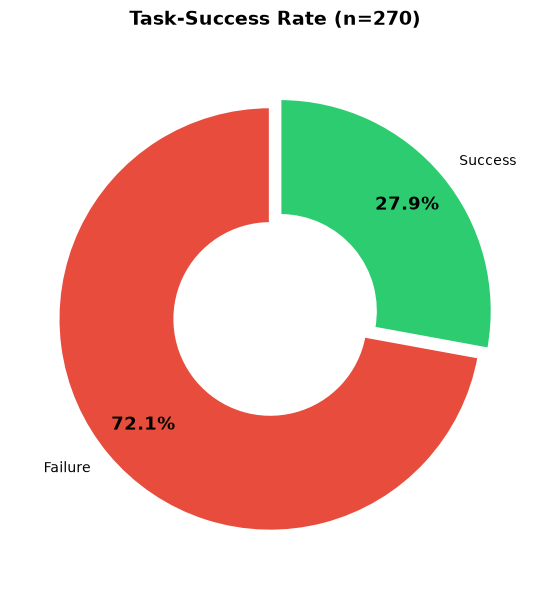

In [20]:
counts = df["task_success"].value_counts()
labels = ["Failure", "Success"]
values = [counts.get(False, 0), counts.get(True, 0)]
colors = ["#e74c3c", "#2ecc71"]
explode = [0.03, 0.03]
# 3. Create Donut / Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values, 
    labels=labels, 
    autopct="%1.1f%%", 
    colors=colors,
    explode=explode, 
    startangle=90, 
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
# Format percentage labels inside chart
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
ax.set_title(f"Task-Success Rate (n={len(df)+1})", pad=18, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_140579/2505855402.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(sc_df.index, rotation=30, ha="right")


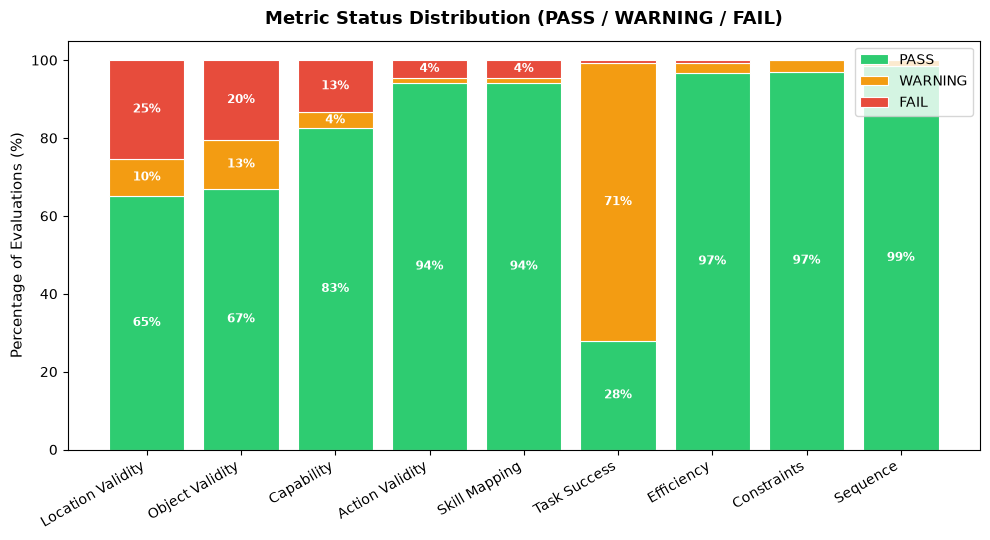

In [11]:
metric_names = [c.replace("metric_", "").replace("_status", "") 
                for c in df.columns if c.endswith("_status")]
metric_status_cols = [f"metric_{m}_status" for m in metric_names]
metric_labels = [m.replace("_", " ").title() for m in metric_names]
# 3. Compute percentage distribution of PASS, WARNING, FAIL per metric
status_counts = {}
for col, label in zip(metric_status_cols, metric_labels):
    vc = df[col].value_counts(normalize=True) * 100
    status_counts[label] = {s: vc.get(s, 0) for s in ["PASS", "WARNING", "FAIL"]}
sc_df = pd.DataFrame(status_counts).T.sort_values("FAIL", ascending=False)
# 4. Plot Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(sc_df))
status_colors = {"PASS": "#2ecc71", "WARNING": "#f39c12", "FAIL": "#e74c3c"}
for status in ["PASS", "WARNING", "FAIL"]:
    vals = sc_df[status].values
    bars = ax.bar(sc_df.index, vals, bottom=bottom,
                  color=status_colors[status], label=status,
                  edgecolor="white", linewidth=0.8)
    
    # Annotate percentage labels inside bar segments (> 4%)
    for bar, v in zip(bars, vals):
        if v > 4:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}%", ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="bold")
    bottom += vals
ax.set_ylabel("Percentage of Evaluations (%)", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Metric Status Distribution (PASS / WARNING / FAIL)", fontsize=13, fontweight="bold", pad=12)
ax.set_xticklabels(sc_df.index, rotation=30, ha="right")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

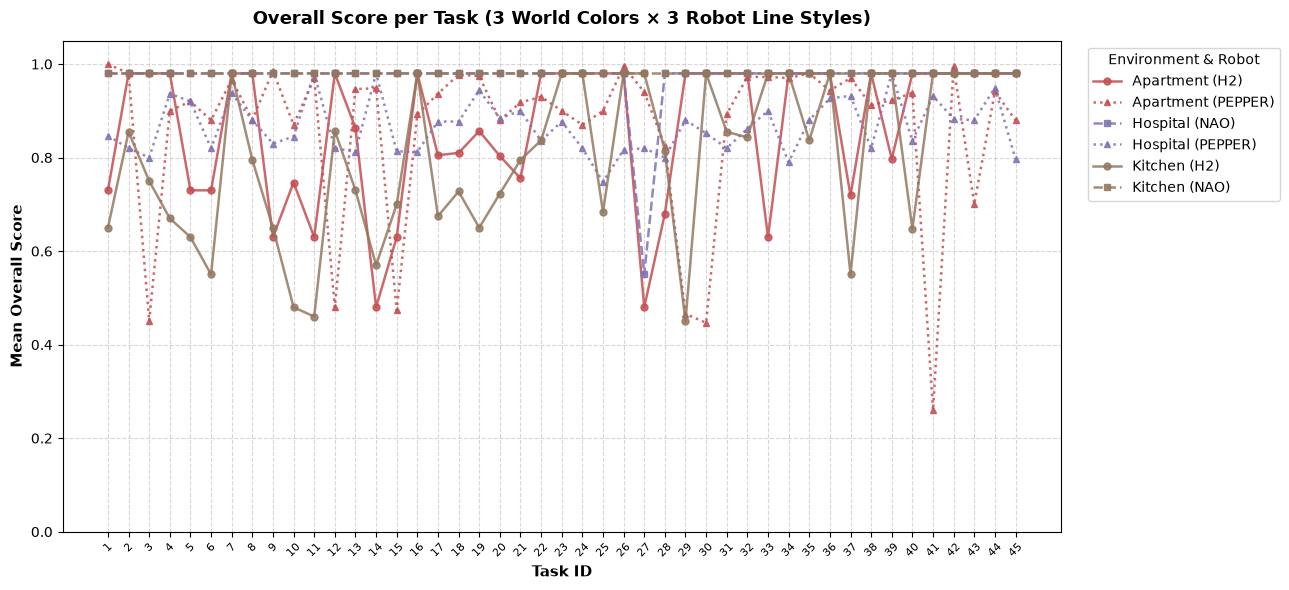

In [12]:
task_scores = df.groupby(["task", "world", "robot"])["overall_score"].mean().reset_index()
# 3. Define 3 distinct colors for Worlds and 3 distinct line styles/markers for Robots
world_colors = {
    "apartment": "#C44E52",  # Red / Coral
    "hospital":  "#8172B2",  # Purple
    "kitchen":   "#937860"   # Brown / Earth
}
robot_styles = {
    "h2":     {"linestyle": "-",  "marker": "o"},  # Solid line, Circle marker
    "nao":    {"linestyle": "--", "marker": "s"},  # Dashed line, Square marker
    "pepper": {"linestyle": ":",  "marker": "^"}   # Dotted line, Triangle marker
}
# 4. Plot score trend across tasks
fig, ax = plt.subplots(figsize=(13, 6))
for (world, robot), group in task_scores.groupby(["world", "robot"]):
    group_sorted = group.sort_values("task")
    ax.plot(
        group_sorted["task"], 
        group_sorted["overall_score"],
        label=f"{world.title()} ({robot.upper()})",
        color=world_colors.get(world, "grey"),
        linestyle=robot_styles.get(robot, {}).get("linestyle", "-"),
        marker=robot_styles.get(robot, {}).get("marker", "o"),
        linewidth=1.8,
        markersize=5,
        alpha=0.85
    )
ax.set_xlabel("Task ID", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean Overall Score", fontsize=11, fontweight="bold")
ax.set_title("Overall Score per Task (3 World Colors × 3 Robot Line Styles)", 
             fontsize=13, fontweight="bold", pad=12)
# Format axes and grid
ax.set_xticks(sorted(df["task"].unique()))
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)
# Legend outside plot area
ax.legend(title="Environment & Robot", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

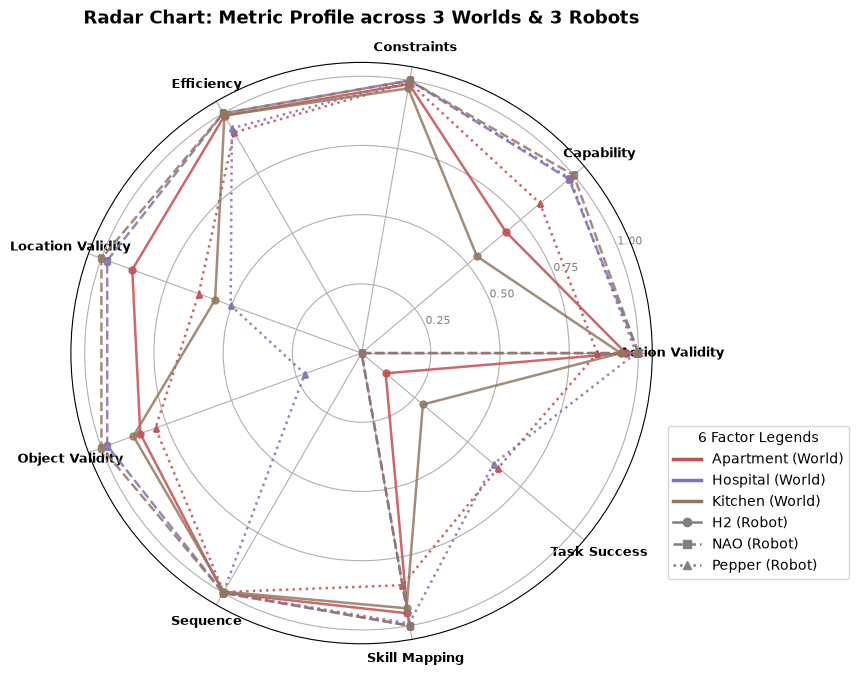

In [18]:
import matplotlib.lines as mlines
metric_names = [c.replace("metric_", "").replace("_score", "") 
                for c in df.columns if c.endswith("_score") and c != "overall_score"]
metric_score_cols = [f"metric_{m}_score" for m in metric_names]
metric_labels = [m.replace("_", " ").title() for m in metric_names]
# 3. Setup radar geometry
num_metrics = len(metric_names)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # Repeat first angle to close polygon loop
# 4. Define 3 World Colors and 3 Robot Line Styles/Markers
world_colors = {
    "apartment": "#C44E52",  # Red / Coral
    "hospital":  "#8172B2",  # Purple
    "kitchen":   "#937860"   # Brown / Earth
}
robot_styles = {
    "h2":     {"linestyle": "-",  "marker": "o"},  # Solid line
    "nao":    {"linestyle": "--", "marker": "s"},  # Dashed line
    "pepper": {"linestyle": ":",  "marker": "^"}   # Dotted line
}
# 5. Create Radar Plot
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
# Group by (world, robot) to compute metric profiles
grouped = df.groupby(["world", "robot"])[metric_score_cols].mean().reset_index()
for _, row in grouped.iterrows():
    world = row["world"]
    robot = row["robot"]
    
    vals = row[metric_score_cols].tolist()
    vals += vals[:1]  # Close loop
    
    ax.plot(
        angles, vals,
        color=world_colors.get(world, "grey"),
        linestyle=robot_styles.get(robot, {}).get("linestyle", "-"),
        marker=robot_styles.get(robot, {}).get("marker", "o"),
        linewidth=1.8,
        markersize=5,
        alpha=0.85
    )
# Set metric labels along the perimeter
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, size=9, fontweight="bold")
# Configure radial grid scale
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=8, color="gray")
# 6. Build 6 Explicit Legend Entries (3 World Colors + 3 Robot Line Styles)
legend_handles = [
    # 3 World Colors
    mlines.Line2D([], [], color="#C44E52", linewidth=2.5, label="Apartment (World)"),
    mlines.Line2D([], [], color="#8172B2", linewidth=2.5, label="Hospital (World)"),
    mlines.Line2D([], [], color="#937860", linewidth=2.5, label="Kitchen (World)"),
    # 3 Robot Line Styles
    mlines.Line2D([], [], color="gray", linestyle="-",  marker="o", linewidth=1.8, label="H2 (Robot)"),
    mlines.Line2D([], [], color="gray", linestyle="--", marker="s", linewidth=1.8, label="NAO (Robot)"),
    mlines.Line2D([], [], color="gray", linestyle=":",  marker="^", linewidth=1.8, label="Pepper (Robot)"),
]
ax.set_title("Radar Chart: Metric Profile across 3 Worlds & 3 Robots", pad=28, fontsize=13, fontweight="bold")
# Display the 6 Legend Items
ax.legend(handles=legend_handles, title="6 Factor Legends", bbox_to_anchor=(1.35, 0.1), loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

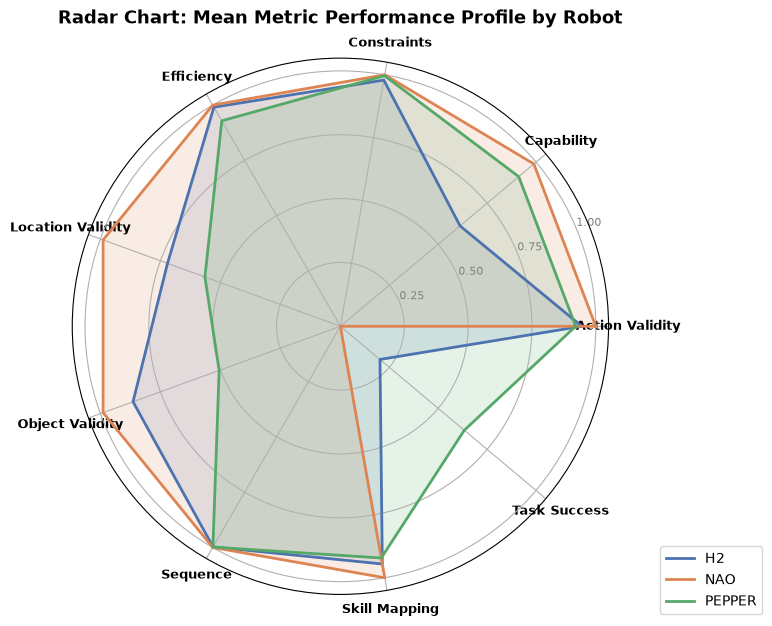

In [16]:
metric_names = [c.replace("metric_", "").replace("_score", "") 
                for c in df.columns if c.endswith("_score") and c != "overall_score"]
metric_score_cols = [f"metric_{m}_score" for m in metric_names]
metric_labels = [m.replace("_", " ").title() for m in metric_names]
# 3. Setup radar geometry (angular axes)
robots = sorted(df["robot"].unique())
num_metrics = len(metric_names)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # Repeat first angle to close the polygon loop
# Distinct color map per robot
robot_colors = {"h2": "#4C72B0", "nao": "#DD8452", "pepper": "#55A868"}
# 4. Create Radar Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for robot in robots:
    # Mean score for each metric
    vals = df[df["robot"] == robot][metric_score_cols].mean().tolist()
    vals += vals[:1]  # Repeat first value to close polygon
    
    ax.plot(
        angles, vals, 
        linewidth=2, 
        label=robot.upper(), 
        color=robot_colors.get(robot, "blue")
    )
    ax.fill(
        angles, vals, 
        alpha=0.15, 
        color=robot_colors.get(robot, "blue")
    )
# Set metric labels along the outer perimeter
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, size=9, fontweight="bold")
# Configure radial scale & grid lines
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=8, color="gray")
ax.set_title("Radar Chart: Mean Metric Performance Profile by Robot", pad=25, fontsize=13, fontweight="bold")
ax.legend(loc="lower right", bbox_to_anchor=(1.3, -0.05), frameon=True)
plt.tight_layout()
plt.show()

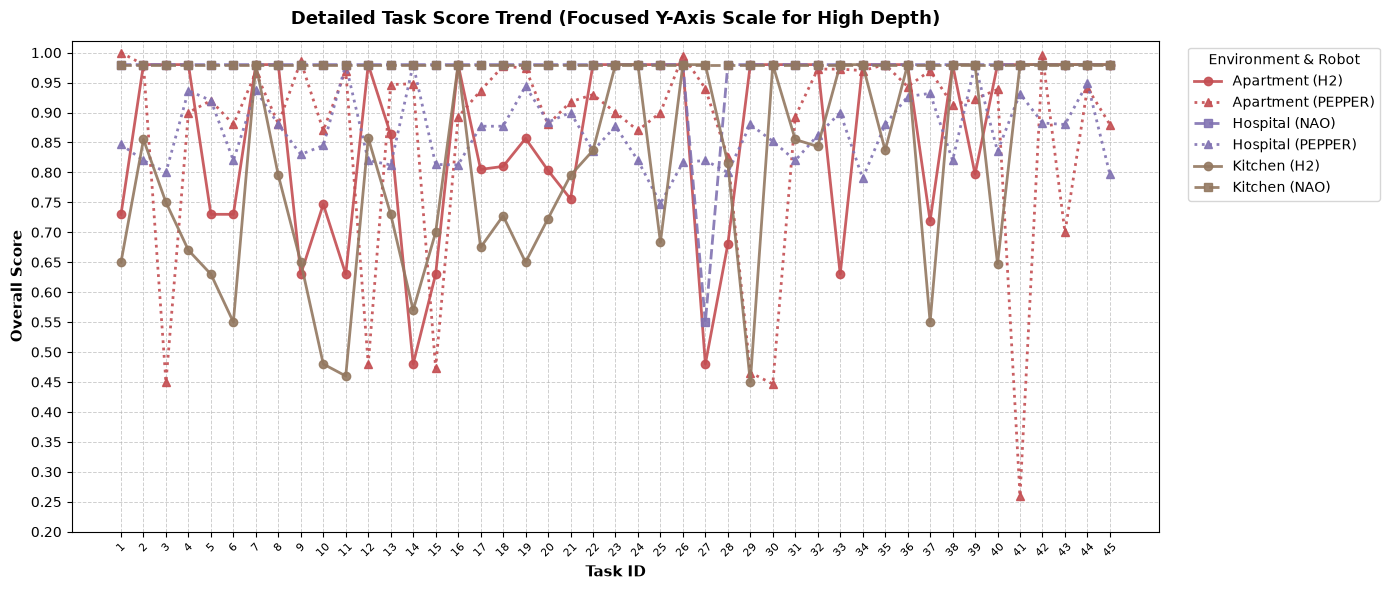

In [13]:
task_scores = df.groupby(["task", "world", "robot"])["overall_score"].mean().reset_index()
# 3. Define 3 distinct colors for Worlds and 3 distinct line styles/markers for Robots
world_colors = {
    "apartment": "#C44E52",  # Red / Coral
    "hospital":  "#8172B2",  # Purple
    "kitchen":   "#937860"   # Brown / Earth
}
robot_styles = {
    "h2":     {"linestyle": "-",  "marker": "o"},  # Solid line, Circle marker
    "nao":    {"linestyle": "--", "marker": "s"},  # Dashed line, Square marker
    "pepper": {"linestyle": ":",  "marker": "^"}   # Dotted line, Triangle marker
}
# 4. Plot score trend across tasks
fig, ax = plt.subplots(figsize=(14, 6))
for (world, robot), group in task_scores.groupby(["world", "robot"]):
    group_sorted = group.sort_values("task")
    ax.plot(
        group_sorted["task"], 
        group_sorted["overall_score"],
        label=f"{world.title()} ({robot.upper()})",
        color=world_colors.get(world, "grey"),
        linestyle=robot_styles.get(robot, {}).get("linestyle", "-"),
        marker=robot_styles.get(robot, {}).get("marker", "o"),
        linewidth=2.0,
        markersize=6,
        alpha=0.9
    )
ax.set_xlabel("Task ID", fontsize=11, fontweight="bold")
ax.set_ylabel("Overall Score", fontsize=11, fontweight="bold")
ax.set_title("Detailed Task Score Trend (Focused Y-Axis Scale for High Depth)", 
             fontsize=13, fontweight="bold", pad=12)
# --- DETAILED Y-AXIS FOCUS & NORMALIZATION ---
# Dynamically scale Y-axis to exact min/max bounds with fine 0.05 step grid
min_score = task_scores["overall_score"].min()
max_score = task_scores["overall_score"].max()
y_min = np.floor((min_score - 0.02) * 20) / 20  # Round down to nearest 0.05
y_max = min(1.02, np.ceil((max_score + 0.02) * 20) / 20)  # Round up to nearest 0.05
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, y_max + 0.01, 0.05)) # Fine 0.05 tick intervals
# Format X-axis and Grid
ax.set_xticks(sorted(df["task"].unique()))
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.grid(True, which="both", linestyle="--", alpha=0.6, linewidth=0.7)
# Legend outside plot
ax.legend(title="Environment & Robot", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

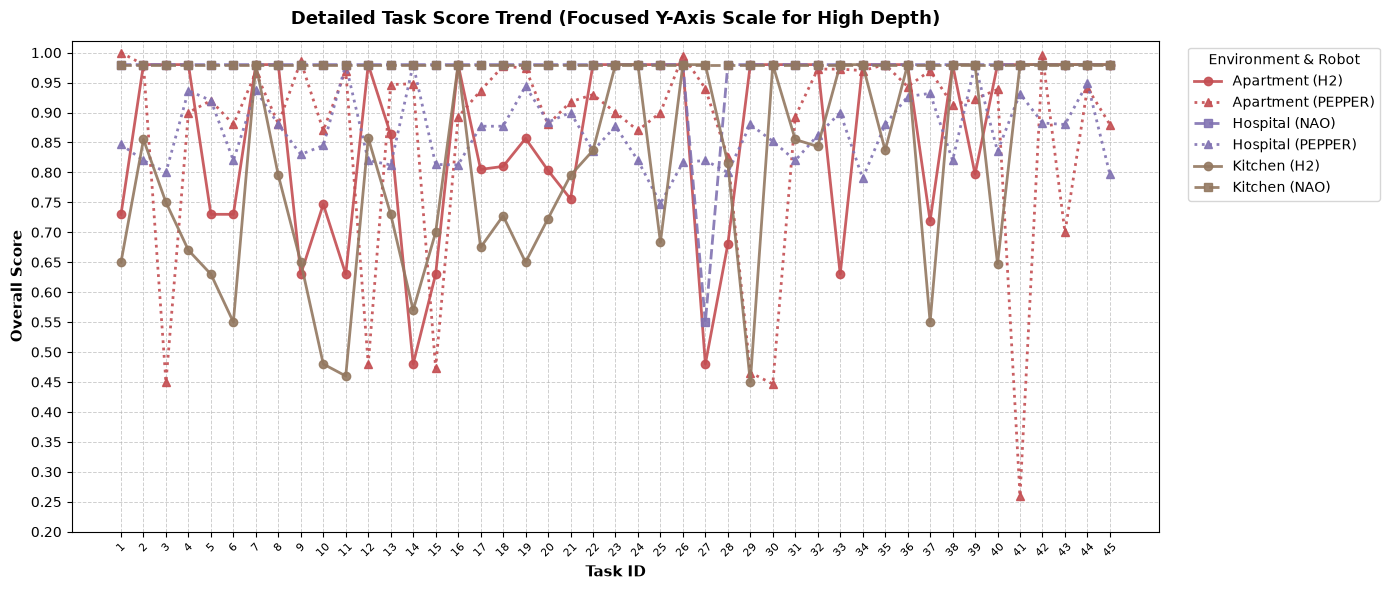

In [15]:
task_scores = df.groupby(["task", "world", "robot"])["overall_score"].mean().reset_index()
# 3. Define 3 distinct colors for Worlds and 3 distinct line styles/markers for Robots
world_colors = {
    "apartment": "#C44E52",  # Red / Coral
    "hospital":  "#8172B2",  # Purple
    "kitchen":   "#937860"   # Brown / Earth
}
robot_styles = {
    "h2":     {"linestyle": "-",  "marker": "o"},  # Solid line, Circle marker
    "nao":    {"linestyle": "--", "marker": "s"},  # Dashed line, Square marker
    "pepper": {"linestyle": ":",  "marker": "^"}   # Dotted line, Triangle marker
}
# 4. Plot score trend across tasks
fig, ax = plt.subplots(figsize=(14, 6))
for (world, robot), group in task_scores.groupby(["world", "robot"]):
    group_sorted = group.sort_values("task")
    ax.plot(
        group_sorted["task"], 
        group_sorted["overall_score"],
        label=f"{world.title()} ({robot.upper()})",
        color=world_colors.get(world, "grey"),
        linestyle=robot_styles.get(robot, {}).get("linestyle", "-"),
        marker=robot_styles.get(robot, {}).get("marker", "o"),
        linewidth=2.0,
        markersize=6,
        alpha=0.9
    )
ax.set_xlabel("Task ID", fontsize=11, fontweight="bold")
ax.set_ylabel("Overall Score", fontsize=11, fontweight="bold")
ax.set_title("Detailed Task Score Trend (Focused Y-Axis Scale for High Depth)", 
             fontsize=13, fontweight="bold", pad=12)
# --- DETAILED Y-AXIS FOCUS & NORMALIZATION ---
# Dynamically scale Y-axis to exact min/max bounds with fine 0.05 step grid
min_score = task_scores["overall_score"].min()
max_score = task_scores["overall_score"].max()
y_min = np.floor((min_score - 0.02) * 20) / 20  # Round down to nearest 0.05
y_max = min(1.02, np.ceil((max_score + 0.02) * 20) / 20)  # Round up to nearest 0.05
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, y_max + 0.01, 0.05)) # Fine 0.05 tick intervals
# Format X-axis and Grid
ax.set_xticks(sorted(df["task"].unique()))
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.grid(True, which="both", linestyle="--", alpha=0.6, linewidth=0.7)
# Legend outside plot
ax.legend(title="Environment & Robot", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [14]:
# Optional: Min-Max Normalization per task line
task_scores["overall_score"] = (task_scores["overall_score"] - min_score) / (max_score - min_score)
